In [1]:
#target:id
#이미지 사이즈, 흑백처리
#해상도 피처컬럼, 로우 16개

In [2]:

import warnings
warnings.filterwarnings('ignore')

import glob
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow import keras

---
####전체 사진 중 최대 해상도 찾기

In [3]:
#1.이미지 크기 맞추기=>피처 정하기
#target=??
#Names
dirNames=['Aiden','Andrew','Cathy']


In [4]:
#각각의 해상도 확인
widthRatio=[]
heightRatio=[]

for name in dirNames:
    for file in sorted(glob.glob(f"../Data/Face/{name}/*.jpg")):
        img=np.array(Image.open(file),dtype=np.int32)
        widthRatio.append(img.shape[1])#0=row,height/1=column,width
        heightRatio.append(img.shape[0])#

In [5]:
print("너비 최대 해상도:", np.max(widthRatio))
print("높이 최대 해상도:", np.max(heightRatio))

너비 최대 해상도: 299
높이 최대 해상도: 381


해상도 크기 결정:400*300
#facegray:CNN

In [6]:
#전체 사진을 400*300의 고정 크기로 검은색을 배경으로 맞추기
#사이드를 검정색으로 패딩:이미지 왜곡 방지
for name in dirNames:
    fileCount=0
    for file in sorted(glob.glob(f"../Data/Face/{name}/*.jpg")):
        img = Image.open(file)
        imgResize= img.convert("L")
        #이미지 크기 알아야함
        imgArray=np.array(imgResize)

        imgDummy=np.zeros(400*300).reshape(400,300)
        rowNum=(400-imgArray.shape[0])/2
        colNum=(300-imgArray.shape[1])/2

        #Empty List에 image array 붙이기
        k = 0
        for i in range(int(rowNum),int(rowNum)+imgArray.shape[0]):
            l =0
            for j in range(int(colNum),int(colNum+imgArray.shape[1])):
                imgDummy[i,j] = imgArray[k,l]
                l+=1
            k+=1

        img2= Image.fromarray(imgDummy.astype('uint8'),'L')
        img2.save(f"../Data/FaceGray/{name}/image_{fileCount:02}.jpg","JPEG")
        fileCount+=1

In [7]:
#이미지 타겟데이터 이미지 2차원 데이터:3차원 데이터 만들어야 시작

####사진들을 numy배열을 이용하여 training data만들기

In [8]:
number_of_data= 18*len(dirNames)
img_width_size=300
img_height_size=400#3차원 데이터
#0값으로 만든뒤 for문

In [9]:
train=np.zeros(number_of_data*img_width_size*img_height_size,
               dtype=np.int32).reshape(number_of_data,img_height_size,img_width_size)#height=row

In [10]:
train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [11]:
train.shape#3차원

(54, 400, 300)

In [12]:
#train data 에 이미지 불러와서 넣어주기
i=0
for name in dirNames:
    for file in sorted(glob.glob(f"../Data/FaceGray/{name}/*.jpg")):
        img = np.array(Image.open(file), dtype=np.int32)#이미지=>배열
        train[i,:,:]=img
        i+=1

In [13]:
train.shape#3차원

(54, 400, 300)

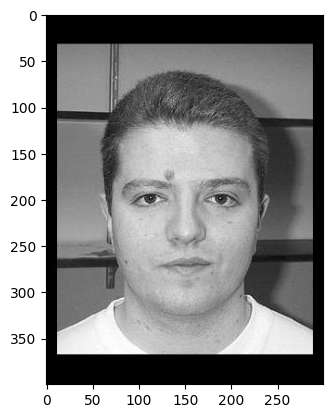

In [14]:
#이미지 확인하기(크기)
import matplotlib.pyplot as plt
plt.imshow(train[0].reshape(400,300),cmap='gray')
plt.show() 

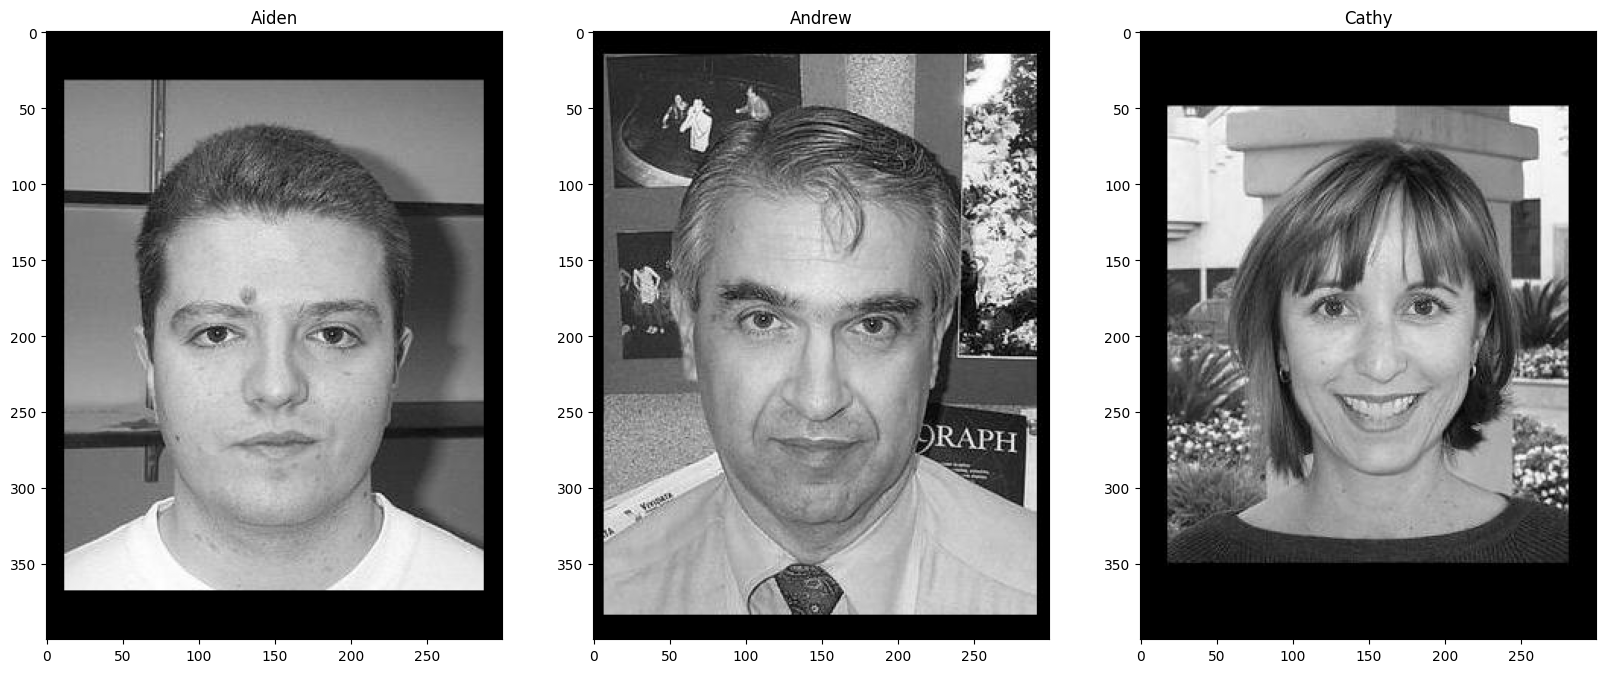

In [15]:
plt.figure(figsize=(20,20))
orderNo=range(0,len(dirNames)*18,18)
# list(orderNo)

for i in range(1,len(dirNames)+1):
    plt.subplot(1,len(dirNames),i)#len=3
    plt.imshow(train[orderNo[i-1]].reshape(400,300),cmap='gray')
    plt.title(dirNames[i-1])#train:3차원

#target data 만들기(숫자로)

In [16]:
target=np.concatenate(
    [np.zeros(18),np.ones(18),np.full(18,2)]
)

In [17]:
len(target)

54

In [18]:
target

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2.])

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    train, target, test_size=0.2, random_state=42, stratify=target
)

In [20]:
X_train = X_train / 255.0
X_test = X_test / 255.0

# CNN 입력 형태: (개수, 32, 32, 1)
X_train = X_train.reshape(-1, 400, 300, 1)
X_test = X_test.reshape(-1, 400, 300, 1)

print("CNN용 X_train shape:", X_train.shape)
print("CNN용 X_test shape :", X_test.shape)

CNN용 X_train shape: (43, 400, 300, 1)
CNN용 X_test shape : (11, 400, 300, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 400, 300, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 200, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 200, 150, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 100, 75, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 480000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    61,440,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,459,331 (234.45 MB)

 Trainable params: 61,459,331 (234.45 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.2353 - loss: 1.2609 - val_accuracy: 0.3333 - val_loss: 3.1268
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 546ms/step - accuracy: 0.4412 - loss: 5.2963 - val_accuracy: 0.3333 - val_loss: 3.6351
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.4118 - loss: 3.8441 - val_accuracy: 0.8889 - val_loss: 0.5113
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 493ms/step - accuracy: 0.7941 - loss: 0.6837 - val_accuracy: 0.7778 - val_loss: 0.9357
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.8824 - loss: 0.4111 - val_accuracy: 0.8889 - val_loss: 0.4910
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.8824 - loss: 0.2714 - val_accuracy: 0.8889 - val_loss: 0.4227
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.9412 - loss: 0.1707 - val_accuracy: 0.8889 - val_loss: 0.3343
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.9706 - loss: 0.1145 - val_accuracy: 0.8889 - val_loss: 0.2448
Epoch 9/20

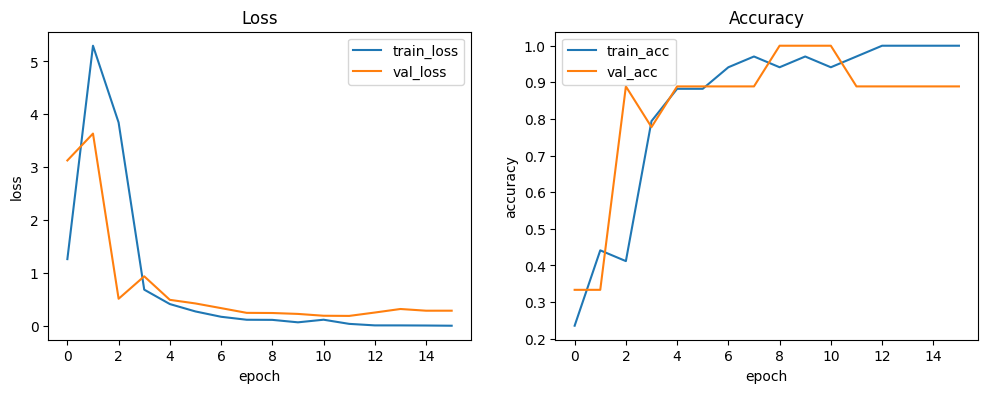

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9767 - loss: 0.0410
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.8889 - loss: 0.1871
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 1.0000 - loss: 0.0129


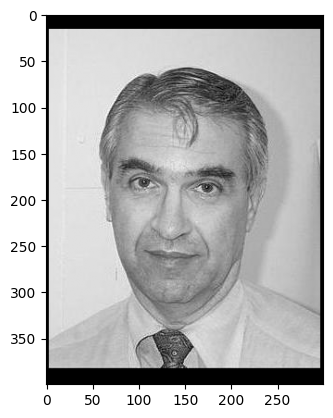

In [21]:
#cnn만들기
# train -> train, valid 분리
train_input, val_input, train_target, val_target = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

model = keras.Sequential()

model.add(keras.layers.Conv2D(
    32,
    kernel_size=3,
    activation='relu',
    padding='same',
    input_shape=(400,300, 1)
))
model.add(keras.layers.MaxPool2D(2))

model.add(keras.layers.Conv2D(
    64,
    kernel_size=3,
    activation='relu',
    padding='same'
))
model.add(keras.layers.MaxPool2D(2))

model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(3, activation='softmax'))

model.summary()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "../Data/best_model.keras",
    save_best_only=True
)
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    train_input,
    train_target,
    epochs=20,
    validation_data=(val_input, val_target),
    callbacks=[checkpoint_cb, early_stopping_cb]
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

train_loss, train_acc = model.evaluate(X_train, y_train)
val_loss, val_acc = model.evaluate(val_input, val_target)
test_loss, test_acc = model.evaluate(X_test, y_test)

# print("train loss:", train_loss)
# print("train accuracy:", train_acc)
# print("val loss:", val_loss)
# print("val accuracy:", val_acc)
# print("test loss:", test_loss)
# print("test accuracy:", test_acc)

plt.imshow(X_test[0].reshape(400,300), cmap='gray')
plt.show()


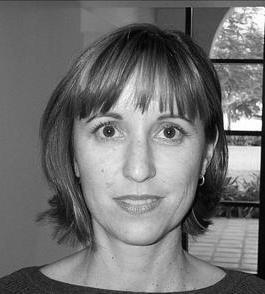

In [22]:
person = Image.open("../Data/image_0000.jpg").convert("L")
person

In [23]:
person.save("../Data/image_00001.jpg")

In [24]:
#early_stop 불러서 예측?
#데이터수가 적어서 널뛰기 계속 바뀜
from PIL import ImageDraw
import random

In [25]:
def add_noise(image1, noise_prob=0.01, color=(255)):#1%,하얀색
    image=image1.copy()
    width,height=image.size
    draw=ImageDraw.Draw(image)
    for x in range(width):
        for y in range(height):
            if random.random()<noise_prob:
             draw.point((x,y), fill=color)

    return image

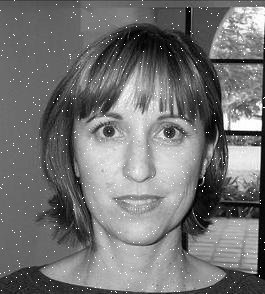

In [26]:
personNoise=add_noise(person)
personNoise#실행시 마다 노이즈 바뀜

In [27]:
#장수 주의 오버라이트?
counter=0
for angle in range(-15,15,1):#1:30 , 0.5:60
    counter+=1
    img2=person.rotate(angle)
    img2.save(f"../Data/personImage_1/{counter:03}.png")

    #반전 데이터 추가(시프트,노이즈 등)
    counter+=1
    img3=img2.transpose(Image.FLIP_LEFT_RIGHT)
    img3.save(f"../Data/personImage_1/{counter:03}.png")

In [28]:
#이미지의 데이터가 조금만 바뀌어도 처리를 못한다?
#이미지를 나눠서 학습 CNN 합성곱 convolution?
#rnn recurrnt 다시 반복(흑백 칼라레이어 하나, 컬러 rgb 3개)
#흑백=>컬러 가장 적은 loss